Download and prepare our dataset

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import tarfile
from sklearn.datasets import load_files

/tmp/ipykernel_36902/3477612667.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# # # Download Data when in google Collab
# !wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
# !tar xvzf aclImdb_v1.tar.gz > /dev/null && rm -rf aclImdb_v1.tar.gz # Extract contents and delete the zipped file

Load files when in collab:

In [3]:
# from sklearn.datasets import load_files

# # Load the files when in Google Collab
# movies_train = load_files(container_path="/content/aclImdb/train", encoding="utf-8")
# movies_test = load_files(container_path="/content/aclImdb/test", encoding="utf-8")




Load file when running local:

In [4]:
# from sklearn.datasets import load_files

# movies_train = load_files(container_path="../../../../../big_files_DS/aclImdb/train", encoding="utf-8")
# movies_test = load_files(container_path="../../../../../big_files_DS/aclImdb/test", encoding="utf-8")
# # print(type(movies_train))

Load files when in wsl:

In [5]:
from sklearn.datasets import load_files
movies_train = load_files(container_path="//home/aclImdb/train", encoding="utf-8")
movies_test = load_files(container_path="//home/aclImdb/test", encoding="utf-8")
# print(type(movies_train))

In [6]:
# Transform train dataset into a dataframe
data_train = {'reviews': movies_train.data, 'sentiment': movies_train.target}
df_train = pd.DataFrame(data_train)

# Transform test dataset into a dataframe
data_test = {'reviews': movies_test.data, 'sentiment': movies_test.target}
df_test = pd.DataFrame(data_test)

del movies_train, movies_test # free memory

print(df_train.iloc[:10])
print('----------------------------------------------------------------------------------------')
print(df_test.iloc[:10])

                                             reviews  sentiment
0  Full of (then) unknown actors TSF is a great b...          2
1  Amount of disappointment I am getting these da...          2
2  The future, we are told, are what we make of i...          2
3  Dan Katzir has produced a wonderful film that ...          1
4  If you want Scream or anything like the big-st...          1
5  Although its mold of 1949 appears somewhat mel...          2
6  Gloomy Sunday - Ein Lied von Liebe und Tod dir...          2
7  This movie was ridiculous. The plot is complet...          2
8  Why was this movie made? No doubt to sucker in...          2
9  Outlandish premise that rates low on plausibil...          0
----------------------------------------------------------------------------------------
                                             reviews  sentiment
0  Don't hate Heather Graham because she's beauti...          1
1  I don't know how this movie has received so ma...          0
2  I caught thi

In [7]:
# Drop rows where 'sentiment' is 2 from train & test sets
df_train = df_train[df_train['sentiment'] != 2]
df_test = df_test[df_test['sentiment'] != 2]


df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

# Define the train dataset with 5000 rows by test set
df_train = pd.concat([df_train, df_test[:5000]])

print(f'The size of training set is: {len(df_train)}')
print(f'The size of test set is: {len(df_test[5000:])}')

The size of training set is: 30000
The size of test set is: 20000


In [8]:
from sklearn.utils import shuffle

# Shuffle dataframes because they are sorted.
df_train = shuffle(df_train)
df_train.reset_index(inplace=True, drop=True)
df_test = shuffle(df_test)
df_test.reset_index(inplace=True, drop=True)

df_train.head()

,reviews,sentiment
0,Can this really be a Troma movie? Some scenes ...,1
1,"Unlike some comments, mine is positive. This m...",1
2,A young Frenchman uproots himself as he become...,1
3,"After some internet surfing, I found the ""Home...",0
4,This Horror movie is definitely one of the bes...,1


In [9]:
X_train = df_train.reviews
y_train = df_train.sentiment

In [10]:
# Split dev and test data
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(df_test.reviews[5000:], df_test.sentiment[5000:], test_size=0.5, random_state=42)
print(f"Number of observations in dev set: {X_dev.shape[0]}")
print(f"Number of observations in test set: {X_test.shape[0]}")

Number of observations in dev set: 10000
Number of observations in test set: 10000


### Plot the length of each class(pos or neg) for each set

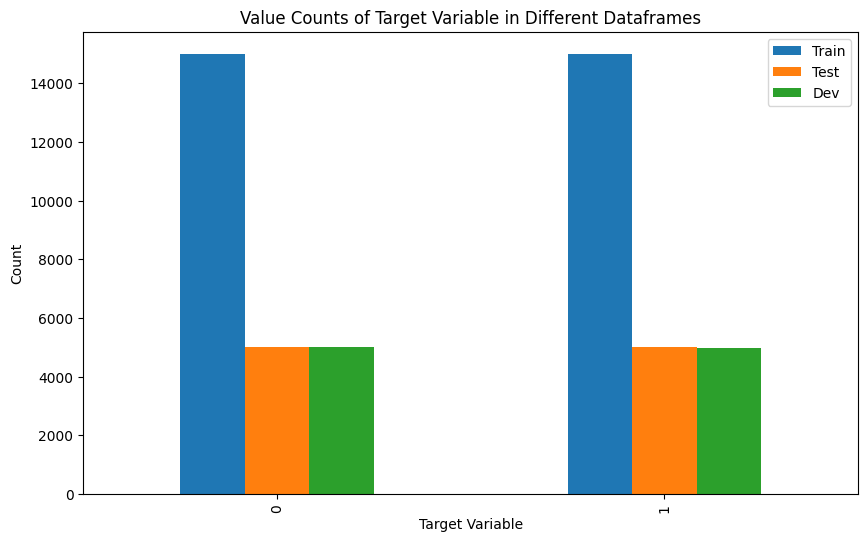

In [11]:

# Count the values of the ground truth (sentiments)
train_counts = y_train.value_counts()
test_counts = y_test.value_counts()
dev_counts = y_dev.value_counts()


# Create a DataFrame with the counts
counts_df = pd.DataFrame({'Train': train_counts, 'Test': test_counts, 'Dev': dev_counts})

# Plot the bar plot
counts_df.plot(kind='bar', figsize=(10, 6))
plt.title('Value Counts of Target Variable in Different Dataframes')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()


### Plot the size of each text for each set

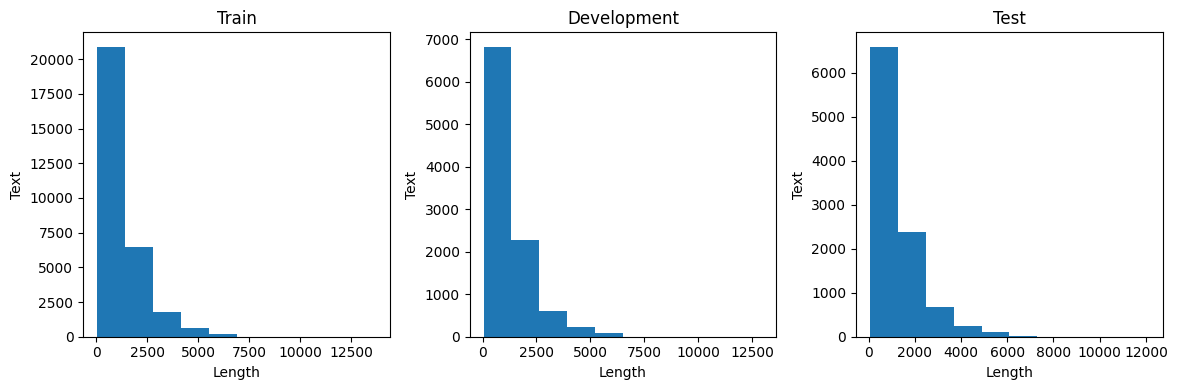

In [12]:
# Function to plot text lengths
def plot_text_lengths(ax, texts, title):
    text_lengths = [len(text) for text in texts]
    ax.hist(text_lengths)
    ax.set_xlabel('Length')
    ax.set_ylabel('Text')
    ax.set_title(title)

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12, 4))

# Plot for texts1
plot_text_lengths(ax1, X_train, 'Train')

# Plot for texts2
plot_text_lengths(ax2, X_dev, 'Development')

plot_text_lengths(ax3, X_test, 'Test')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()

# Preprocessing

* Replace non-word characters and numbers with empty string.
* Substitute multiple spaces with single space.
* Convert to lowercase.
* Remove stop words.
* Stemming with WordNetLemmatizer.

In [13]:
# Imports we need for preprocessing
import re
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

stemmer = WordNetLemmatizer()

# Import stop words for preprocessing
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to /home/meizeus/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/meizeus/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/meizeus/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
import re
def preprocess(contents):

    """
        Preprocesses a list of texts by removing non-word characters, single characters, extra spaces,
    converting to lowercase, splitting into words, lemmatizing, and reconstructing the documents.
    :param contents: A list of texts to be preprocessed
    :return: A Pandas Series containing preprocessed documents.
    """


    docs = []

    for doc in contents:
        # Convert the text to lowercase
        doc = doc.lower()

        # Delete all the non-word characters for the data frame
        document = re.sub(r'[^a-zA-Z\s]', '', str(doc))


        # Split the document based on whitespaces (--> List of words)
        word_list = document.split()

        word_list = [word for word in word_list if word not in (stop_words)]

        # Lemmatization
        word_list = [stemmer.lemmatize(word) for word in word_list]

        # Reconstruct the document by joining the words on each whitespace
        document = ' '.join(word_list)

        # Append all documents into a list 'docs'
        docs.append(document)
    return pd.Series(docs)

In [15]:
# Preprocess texts
X_train = preprocess(X_train)
X_dev = preprocess(X_dev)
X_test = preprocess(X_test)

### Example

In [ ]:
# Example of a preprocessed text
print(f'The non processed text:\n {df_train.reviews.iloc[10]}')
print('------------------------------------------------------------------------------------')
print('VS')
print('------------------------------------------------------------------------------------')
print(f'The processed text:\n {X_train[10]}')

The non processed text:
 I'm so confused. I've been a huge Seagal fan for 25 years. I've seen all of his films, and many of those dozens of times. I can only describe this film as "bizarre." Steven Seagal shares screenplay writing and producing credits on this film, but I have a really tough time believing he would choose to dub over his own voice for so many of his lines, with a thin, whiny imposter's voice no less. What I also don't get is, if they had to dub SOME of his lines, why does his own voice appear on the rest of them? I expect Seagal to age like the rest of us. But the Seagal in this movie barely exudes a fraction of the same swagger, confidence, bravado, charm, and sex-appeal he so easily showed us in ALL of his previous movies. What I found myself missing most of all was his cocky, self-assured attitude and his bad-ass sneer that so easily shifts into that adorable grin. Where is that in-your-face attitude and charm that made him such a huge star??? I hope that this film 

## Baseline Model-1 (LogisticRegression)

* The dataset we are using in this notebook was used in exercise 9 part 3

* So, we know that TF-IDF with SVD provide the best results for the baseline model.



# TF-IDF Vectorization


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use unigram & bi-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range=(1, 3),
                             max_features = 5000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_dev_tfidf = vectorizer.transform(X_dev)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, type(X_train_tfidf))

(30000, 5000) <class 'scipy.sparse._csr.csr_matrix'>


## Dimensionality reduction via SVD method

In [ ]:
# Reduce dimensionality using SVD 5000 --> 500
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=1000, random_state=4321)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_dev_svd = svd.transform(X_dev_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print(X_train_svd.shape, type(X_train_svd))

(30000, 1000) <class 'numpy.ndarray'>


### (Baseline 1) Build a Logistic Regression Baseline


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve, auc
clf = LogisticRegression()
clf.fit(X_train_svd.tolist(), y_train)

# Validation set prediction
predictions = clf.predict(X_dev_svd.tolist())
print(f"\t\tClassification Report for developement set:\n\n {classification_report(y_dev, predictions)}")

# Test set prediction
predictions2 = clf.predict(X_test_svd.tolist())
print(f"\n\n\t\tClassification Report for testing set:\n\n {classification_report(y_test, predictions2)}")



		Classification Report for developement set:

               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4989
           1       0.88      0.90      0.89      5011

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



		Classification Report for testing set:

               precision    recall  f1-score   support

           0       0.89      0.88      0.88      4973
           1       0.88      0.89      0.89      5027

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



### Convert labels to 1-hot vectors(optinal for binary classification)

In [ ]:
import tensorflow as tf

y_train_1_hot = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_dev_1_hot = tf.keras.utils.to_categorical(y_dev, num_classes=2)


print(f"Y_train 1 hot: {y_train_1_hot}", "\n\n",f"Y_dev 1 hot:{y_dev_1_hot}")

2024-02-29 20:34:12.454892: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-29 20:34:12.853911: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-29 20:34:13.757210: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/meizeus/miniconda3/envs/tf_env/lib/:/home/meizeus/miniconda3/envs/tf_env/lib/
2024-02-29 20:34:13.759122: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'lib

Y_train 1 hot: [[1. 0.]
 [0. 1.]
 [1. 0.]
 ...
 [1. 0.]
 [0. 1.]
 [1. 0.]] 

 Y_dev 1 hot:[[1. 0.]
 [0. 1.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


### (Baseline 2) Build the MLP Model of exercise 9 Part 3

In [16]:
# Import libraries
# Import libraries
import keras
from keras.layers import InputLayer
from keras.layers import Activation, Dropout, Dense, Input,BatchNormalization, Flatten, Embedding
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.preprocessing.text import Tokenizer
# from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split


def create_MLP_model(input_dim, activation_dense_layers):
    """
    Create a deep feed forward network with Dense layers
    Add techniques such as dropout and Batch Normalization
    :param input_dum: integer for the dimension of the input layer)
    :param  activation_dense_layers: string, for the activation function
    :return: class keras.src.engine

    """
    mlp_model = Sequential()

    # Add InputLayer with specified input dimension
    mlp_model.add(InputLayer(input_shape=(input_dim,)))

    # First Layer
    mlp_model.add(Dense(128, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.4))
    # Second Layer
    mlp_model.add(Dense(512, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.5))
    # Third Layer
    mlp_model.add(Dense(128, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.4))
    # Output Layer
    mlp_model.add(Dense(1, activation='sigmoid'))


    return mlp_model


2024-03-03 13:20:09.679010: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-03 13:20:09.804615: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-03 13:20:10.280650: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/meizeus/miniconda3/envs/tf_env/lib/
2024-03-03 13:20:10.282088: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_

### Custom Keras callback for calculating F1, precision, recall at the end of each epoch

In [17]:
class Metrics(Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict_proba = self.model.predict(self.validation_data[0])
        val_predict = (val_predict_proba > 0.5).astype(int)  # Convert probabilities to classes

        val_targ = self.validation_data[1]

        _val_f1 = f1_score(val_targ, val_predict, average="binary")
        _val_recall = recall_score(val_targ, val_predict, average="binary")
        _val_precision = precision_score(val_targ, val_predict, average="binary")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %.3f — val_precision: %.3f — val_recall: %.3f" % (_val_f1, _val_precision, _val_recall))


In [18]:
from sklearn.metrics import f1_score, recall_score, precision_score

adam = Adam(learning_rate = 0.00004)

mlp = create_MLP_model(X_train_svd.shape[1],'relu')
mlp.compile(
    loss='binary_crossentropy',
    optimizer=adam,
    metrics=["accuracy"]
    )

# Build the model and print the structure of our model before training
mlp.build(X_train_svd.shape[1])  # We need to build our model in order to print the structure
print(mlp.summary())

# Add an early stopping callback to stop the epochs when we catch the best validation loss
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss for early stopping
    patience=10,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore best model weights when early stopping is triggered
)

# Callback to save the Keras model or model weights at some frequency.
MLP_checkpoint = ModelCheckpoint(
    'checkpoints/weights.hdf5',
    monitor='val_loss',
    mode='min',
    verbose=2,
    save_best_only=True,
    save_weights_only=True
    )

# Start our training
history = mlp.fit(
    X_train_svd,
    y_train,
    validation_data=(X_dev_svd, y_dev),
    batch_size=128,
    epochs=65,
    shuffle=True,
    callbacks=[early_stopping_callback]
)

NameError: name 'X_train_svd' is not defined

In [ ]:
from keras import backend as K
K.clear_session()

In [ ]:
# Evaluate in test set
evaluation = mlp.evaluate(X_test_svd, y_test)

print('Test Set Evaluation:')
print(f"The loss of the test set is:{evaluation[0]: .3f},\nThe accuracy of the test set is:{evaluation[1]*100: .3f}%")

# del mlp,clf # Save up memory

313/313 [==============================] - 0s 1ms/step - loss: 0.2722 - accuracy: 0.8889
Test Set Evaluation:
The loss of the test set is: 0.272,
The accuracy of the test set is: 88.890%


### Tokenize X_train, X_dev, X_test

In [ ]:
def is_number(s):
    try:
        float(s)
        return True
    except ValueError:
        return False

In [ ]:
import spacy
import string
import numpy as np
from tqdm import tqdm

nlp = spacy.load('en_core_web_sm', disable=["tagger", "parser", "ner", "lemmatizer"])
from spacy.lang.en.stop_words import STOP_WORDS
nlp.add_pipe('sentencizer')


# Create a function that uses spacy to tokenize sentences and returns a nested list of tokenized sentences
def tokenize_data (data):
  """
    
    :param data: list of documents
    :return: nested list of the tokenized documents
    """
  data_tokenized = []
  for idx in tqdm(range(len(data))):
    doc = nlp(data[idx])
    tokens = []
    for sent in doc.sents:
      for tok in sent:
        if '\n' in tok.text or "\t" in tok.text or "--" in tok.text or "*" in tok.text or\
        tok.text.lower() in STOP_WORDS or tok.text in string.punctuation or\
          all(x in string.punctuation for x in tok.text) or is_number(tok.text):
          continue
        if tok.text.strip():
          tokens.append(tok.text.replace('"',"'").strip().lower())
    data_tokenized.append(tokens)
  return data_tokenized

X_train_tokenized = tokenize_data(X_train) 
X_dev_tokenized = tokenize_data(X_dev)
X_test_tokenized = tokenize_data(X_test)



100%|██████████| 10000/10000 [01:07<00:00, 148.71it/s]


### CHECK THE SEQUENCE LENGTH

* We are going to check the length of each review and drop the reviews that exceed the max sequence length that we will add to our RNN model.

In [ ]:
mean_words = np.mean([len(x) for x in X_train_tokenized])
std_of_words = np.std([len(x) for x in X_train_tokenized])
               
# Get mean and std of sequence length on trainning set
print(f"Mean: {np.mean([len(x) for x in X_train_tokenized]): .2f}")
print(f"Std: {np.std([len(x) for x in X_train_tokenized]): .2f}")

Mean:  106.18
Std:  81.05


* LETS KEEP THE REVIEWS WITH MAX LENGTH= mean_words * (2 * std_of_word_counts)

In [ ]:
print(f"{[len(x) for x in X_train_tokenized]}")

# Define a function that drops the rows not meeting the criteria
def estimate_max_seq_len(data_tokenized, targets, mean_w=mean_words, std_w=std_of_words):
    # Create a DataFrame to work with
    data = pd.DataFrame(columns=['data_tokenized', 'word_counts', 'targets'])

    # Assign the tokenized text to a column inside the dataframe
    data.data_tokenized =  data_tokenized
    # Assign the word counts for each row in a second column
    data.word_counts = [len(x) for x in data_tokenized]

    # Assign target variables
    data.targets = targets

    display(data.head())

    # Custom formula of estimating the MAX_words_Length
    MAX_words_length = mean_w + 2*std_w

    # Drop the rows not meeting the criteria
    data = data[data.word_counts <= MAX_words_length]

    return [' '.join(x) for x in data.data_tokenized], data.targets

X_train, y_train = estimate_max_seq_len(X_train_tokenized, y_train)
# X_dev = estimate_max_seq_len(X_dev_tokenized, y_dev)
# X_test = estimate_max_seq_len(X_test_tokenized, y_test)



[358, 78, 122, 95, 103, 156, 107, 48, 107, 58, 70, 79, 57, 52, 34, 56, 110, 142, 58, 126, 85, 444, 166, 41, 61, 175, 78, 108, 237, 60, 9, 61, 28, 202, 137, 22, 398, 179, 59, 195, 149, 82, 56, 87, 9, 67, 144, 71, 68, 57, 97, 194, 92, 57, 165, 182, 95, 156, 28, 59, 311, 82, 86, 73, 62, 117, 51, 64, 52, 49, 49, 85, 241, 49, 214, 82, 108, 72, 166, 49, 62, 98, 72, 224, 68, 27, 47, 57, 44, 114, 16, 143, 112, 116, 56, 205, 248, 100, 59, 56, 79, 56, 104, 169, 144, 91, 49, 137, 71, 162, 153, 69, 64, 127, 62, 46, 96, 96, 350, 107, 128, 218, 37, 43, 56, 81, 102, 46, 54, 171, 62, 110, 100, 169, 65, 49, 105, 139, 46, 62, 60, 24, 131, 367, 194, 102, 170, 58, 186, 76, 70, 114, 95, 58, 187, 97, 78, 85, 27, 194, 130, 140, 81, 127, 53, 119, 146, 196, 74, 74, 26, 201, 100, 71, 121, 97, 203, 69, 107, 68, 22, 75, 187, 53, 88, 66, 96, 131, 96, 54, 99, 85, 27, 50, 74, 37, 75, 51, 232, 114, 72, 73, 72, 264, 123, 65, 66, 25, 57, 80, 67, 126, 134, 73, 41, 54, 99, 26, 283, 48, 36, 61, 77, 56, 41, 109, 149, 168, 

,data_tokenized,word_counts,targets
0,"[dramatic, license, hate, necessary, retelling...",358,1
1,"[e, elia, merhiges, existentialist, experiment...",78,1
2,"[fan, snoop, dogg, actor, anxious, check, flic...",122,1
3,"[remember, watching, film, ago, seeing, mile, ...",95,1
4,"[greenaways, film, pose, clever, erudite, inno...",103,0


* The new X_train 

### Convert text (sequence of words) to sequence of indexes and PAD the sequences
Using Keras's <a href='https://keras.io/api/layers/preprocessing_layers/core_preprocessing_layers/text_vectorization/'>TextVectorization layer </a>

In [19]:
import tensorflow as tf
MAX_WORDS = 100000
MAX_SEQUENCE_LENGTH = 266 # mean + (2 * std)
EMBEDDING_DIM = 300

vectorizer = tf.keras.layers.TextVectorization(max_tokens=MAX_WORDS, output_mode='int',
                                               ngrams=1, output_sequence_length=MAX_SEQUENCE_LENGTH)

vectorizer.adapt(X_train)

2024-03-03 13:20:18.269329: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-03 13:20:18.297012: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-03 13:20:18.297076: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:08:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-03 13:20:18.297453: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate

#### Initialize embedding matrix with fasttext pre-trained embedings

In [20]:
# !pip install fasttext-wheel

import fasttext
import numpy as np
import fasttext.util


# Download model when running local
"""
First go to the directory of your choice(using command <cd> from terminal)
 and download the model via:
$ python

>>>pip install fasttext-wheel

>>>import fasttext
>>>import numpy as np
>>> import fasttext.util
>>>fasttext.util.download_model('en', if_exists='ignore') # English

Then uncomment the following code and load from the desired folder it was
downloaded!
"""
fasttext_model = fasttext.load_model('../../../../../big_files_DS/cc.en.300.bin')

# On laptop
# fasttext_model = fasttext.load_model('C:/Users/stath/Desktop/big_files_DS/cc.en.300.bin')


""" When in google collab we just need to download and load"""

# # Download model when in Google Collab
# fasttext.util.download_model('en', if_exists='ignore') # English
# fasttext_model =  fasttext.load_model('cc.en.300.bin')




embedding_matrix = np.zeros(shape=(MAX_WORDS, 300))

for w2idx, _word in enumerate(vectorizer.get_vocabulary()):
    # Skip PAD and UNK tokens
    if w2idx >= 2:
      embedding_matrix[w2idx] = fasttext_model.get_word_vector(_word)


In [21]:
# Example of the embeddings matrix
print(embedding_matrix[0,:])

del fasttext_model # save memory

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


* Class with functions that produce the training history for each epoch

In [22]:
from sklearn.metrics import f1_score, recall_score, precision_score
import os


class Metrics(tf.keras.callbacks.Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict = np.argmax(self.model.predict(self.validation_data[0]), -1)
        val_targ = self.validation_data[1]
        val_targ = tf.cast(val_targ,dtype=tf.float32)
        if len(val_targ.shape) == 2 and val_targ.shape[1] != 1:
          val_targ = np.argmax(val_targ, -1)


        _val_f1 = f1_score(val_targ, val_predict,average="weighted")
        _val_recall = recall_score(val_targ, val_predict,average="weighted")
        _val_precision = precision_score(val_targ, val_predict,average="weighted")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %f — val_precision: %f — val_recall: %f" % (_val_f1, _val_precision, _val_recall))
        return

#### Create a function that calculates both the acurracy and loss history for an RNN model 

In [23]:
def accuracy_loss_history(history):
    

    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper left')
    plt.xticks([x_tick for x_tick in range(0,len(history.history['accuracy'])+2,2)])
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper right')
    plt.xticks([x_tick for x_tick in range(0,len(history.history['accuracy'])+2,2)])
    plt.show()


### Create functions that initialize the Self Attention Mechanism given an RNN model 

In [24]:
class SelfAttention(tf.keras.layers.Layer):
  def __init__(self, mlp_layers=0, units=0, dropout_rate=0, return_attention=False, **kwargs):
    super(SelfAttention, self).__init__(**kwargs)
    self.mlp_layers = mlp_layers
    self.mlp_units = units
    self.return_attention = return_attention
    self.dropout_rate = dropout_rate
    self.attention_mlp = self.build_mlp()

  def build_mlp(self):
    mlp = tf.keras.Sequential()
    for i in range(self.mlp_layers):
      mlp.add(tf.keras.layers.Dense(self.mlp_units, activation='relu'))
      mlp.add(tf.keras.layers.Dropout(self.dropout_rate))
    mlp.add(tf.keras.layers.Dense(1))
    return mlp

  def call(self, x, mask=None):
    a = self.attention_mlp(x)
    a = tf.squeeze(a, axis=-1)

    if mask is not None:
      mask = tf.keras.backend.cast(mask, tf.keras.backend.floatx())
      a -= 100000.0 * (1.0 - mask)

    a = tf.keras.backend.expand_dims(tf.keras.backend.softmax(a, axis=-1))
    weighted_input = x * a
    result = tf.keras.backend.sum(weighted_input, axis=1)

    if self.return_attention:
      return [result, a]
    return result


### BiGRU + deep self-attention

In [ ]:
GRU_SIZE = 300
DENSE = 1000

# create empty sequential model
biGRU_deep_selfatt = tf.keras.Sequential()
biGRU_deep_selfatt.add(tf.keras.layers.Input(shape=(1,), dtype=tf.string))
biGRU_deep_selfatt.add(vectorizer)
# add an embedding layer
biGRU_deep_selfatt.add(tf.keras.layers.Embedding(MAX_WORDS, EMBEDDING_DIM, weights=[embedding_matrix],
                    input_length=MAX_SEQUENCE_LENGTH, mask_zero=True, trainable=False))

# Use 0.33 dropout probabillity
biGRU_deep_selfatt.add(tf.keras.layers.Dropout(0.33))
# add a bidirectional gru layer
biGRU_deep_selfatt.add(tf.keras.layers.Bidirectional(tf.keras.layers.GRU(GRU_SIZE, return_sequences=True)))

# Add a self-attention MLP (2 hidden layers)
biGRU_deep_selfatt.add(SelfAttention(mlp_layers=2, units=GRU_SIZE*2, dropout_rate=0.33 ))


# add an MLP output layer
biGRU_deep_selfatt.add(tf.keras.layers.Dense(units=DENSE, activation='relu' ))
biGRU_deep_selfatt.add(tf.keras.layers.Dropout(0.33))
biGRU_deep_selfatt.add(tf.keras.layers.Dense(1, activation='sigmoid'))
print(biGRU_deep_selfatt.summary())

biGRU_deep_selfatt.compile(loss='binary_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               metrics=["accuracy"])


early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Callback to save the Keras model or model weights at some frequency.
MLP_checkpoint = ModelCheckpoint(
    'checkpoints/weights3',
    monitor='val_loss',
    mode='min',
    verbose=2,
    save_best_only=True,
    save_weights_only=True,
    save_format='tf'
)


history3 = biGRU_deep_selfatt.fit(np.array(X_train), y_train,
              validation_data=(np.array(X_dev), y_dev),
              batch_size=256,
              epochs=20,
              shuffle=True,
              callbacks=[Metrics(valid_data=(np.array(X_dev), y_dev))])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, 266)               0         
 ctorization)                                                    
                                                                 
 embedding_1 (Embedding)     (None, 266, 300)          30000000  
                                                                 
 dropout_4 (Dropout)         (None, 266, 300)          0         
                                                                 
 bidirectional_2 (Bidirecti  (None, 266, 600)          1083600   
 onal)                                                           
                                                                 
 self_attention_1 (SelfAtte  (None, 600)               721801    
 ntion)                                                          
                                                      

c:\Users\drago\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


313/313 [==============================] - 44s 141ms/step
 — val_f1: 0.332112 — val_precision: 0.248901 — val_recall: 0.498900
118/118 [==============================] - 345s 3s/step - loss: 0.3249 - accuracy: 0.8623 - val_loss: 0.2973 - val_accuracy: 0.8753 - val_f1: 0.3321 - val_recall: 0.4989 - val_precision: 0.2489
Epoch 3/20


c:\Users\drago\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


313/313 [==============================] - 44s 141ms/step
 — val_f1: 0.332112 — val_precision: 0.248901 — val_recall: 0.498900
118/118 [==============================] - 344s 3s/step - loss: 0.3095 - accuracy: 0.8707 - val_loss: 0.3049 - val_accuracy: 0.8673 - val_f1: 0.3321 - val_recall: 0.4989 - val_precision: 0.2489
Epoch 4/20


...

c:\Users\drago\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


313/313 [==============================] - 56s 178ms/step
 — val_f1: 0.332112 — val_precision: 0.248901 — val_recall: 0.498900
118/118 [==============================] - 356s 3s/step - loss: 0.1797 - accuracy: 0.9269 - val_loss: 0.2477 - val_accuracy: 0.9068 - val_f1: 0.3321 - val_recall: 0.4989 - val_precision: 0.2489
Epoch 20/20


c:\Users\drago\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


313/313 [==============================] - 56s 179ms/step
 — val_f1: 0.332112 — val_precision: 0.248901 — val_recall: 0.498900
118/118 [==============================] - 357s 3s/step - loss: 0.1726 - accuracy: 0.9311 - val_loss: 0.2441 - val_accuracy: 0.9055 - val_f1: 0.3321 - val_recall: 0.4989 - val_precision: 0.2489


c:\Users\drago\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


#### BiGRU + deep self-attention -- Classification Report

In [ ]:
predictions = biGRU_deep_selfatt.predict(np.array(X_dev))
predictions = np.array([[1] if pred >= 0.5 else [0] for pred in predictions])

print(classification_report(y_dev, predictions))

313/313 [==============================] - 58s 184ms/step
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4989
           1       0.90      0.91      0.91      5011

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



# **CNNs**

* Custom functions to calculate precision recall, f1-score and accuracy.


# !need to fix the following (maybe add deepself attention)

In [25]:
import tensorflow.keras.backend as K

def recall(y_true, y_pred):

    """
    Recall metric.
    Only computes a batch-wise average of recall.
    Computes the recall, a metric for multi-label classification of
    how many relevant items are selected.
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall


def precision(y_true, y_pred):

    """
    Precision metric.
    Only computes a batch-wise average of precision.
    Computes the precision, a metric for multi-label classification of
    how many selected items are relevant.
    Source
    ------
    https://github.com/fchollet/keras/issues/5400#issuecomment-314747992
    """
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision


def f1(y_true, y_pred):

    """Calculate the F1 score."""
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * ((p * r) / (p + r))


def accuracy(y_true, y_pred):
    return K.mean(K.equal(y_true, K.round(y_pred)), axis=1)

### **Stacked CNNs followed by Max-Pooling**


In [ ]:
# Create and train a CNN model with trigram filters
import os
from keras.callbacks import EarlyStopping
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


FILTERS = 128  # the dimensionality of the output space (i.e. the number of output filters in the convolution)
KERNEL = 3  # the length of the 1D convolution window
DENSE = 64
N_CLASSES = 1 # Binary Classificaton

# create empty sequential model
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(1,), dtype=tf.string))
model.add(vectorizer)  # string to int!
# add an embedding layer
model.add(tf.keras.layers.Embedding(input_dim=MAX_WORDS, # Size of the vocabulary, i.e. maximum integer index + 1
                                    output_dim=EMBEDDING_DIM,
                                    weights=[embedding_matrix],
                                    input_length=MAX_SEQUENCE_LENGTH,
                                    mask_zero=True,
                                    trainable=False))
# add 0.2 dropout probabillity
model.add(tf.keras.layers.Dropout(0.2))
# add a stack of convolution layers
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
model.add(tf.keras.layers.Conv1D(filters=FILTERS, kernel_size=KERNEL,
                                 activation='relu', padding='valid'))
# max pooling
model.add(tf.keras.layers.GlobalMaxPooling1D())
# add 0.2 dropout probabillity
model.add(tf.keras.layers.Dropout(0.2))

# add a self-attention MLP (2 hidden layers)
model.add(SelfAttention(mlp_layers=1, units=EMBEDDING_DIM, dropout_rate=0.33))

# add dense layer
model.add(tf.keras.layers.Dense(DENSE, activation='relu'))
# add final linear layer
model.add(tf.keras.layers.Dense(N_CLASSES, activation='sigmoid'))

print(model.summary())

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)              
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=[precision, recall, f1, accuracy])
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'checkpoints/keras_CNN_model', monitor='val_f1', verbose=1,
    save_best_only=True, mode='max'
    )
history = model.fit(np.array(X_train), y_train,
              batch_size=32,
              epochs=100,
              verbose = 1,
              callbacks=[checkpoint, early_stopping_callback],
              validation_data=(np.array(X_dev), y_dev),
              shuffle=True)

ValueError: Input 0 of layer "dense_11" is incompatible with the layer: expected min_ndim=2, found ndim=1. Full shape received: (None,)

In [26]:
def training_history(history):
    %matplotlib inline
    import matplotlib.pyplot as plt

    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper left')
    plt.show()

    # summarize history for f1
    plt.plot(history.history['f1'])
    plt.plot(history.history['val_f1'])
    plt.title('model f1')
    plt.ylabel('f1')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper left')
    plt.show()

    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'dev'], loc='upper right')
    plt.show()

training_history(history)

NameError: name 'history' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def predict_data(data):
    T = model.predict(data)
    # T2 = np.zeros_like(T)
    # for i in range(T.shape[0]):
    #   T2[i] = T[i]/np.max(T[i])
    C = np.ones((T.shape[1],)) / 2
    T = (C<=T)
    return T*1


print(f'Dev accuracy: {accuracy_score(y_dev, predict_data(X_dev))*100:.2f}%')
print(f'Dev micro-f1: {f1_score(y_dev, predict_data(X_dev), average="micro")*100:.2f}%')
print(f'Test accuracy: {accuracy_score(y_test, predict_data(X_test))*100:.2f}%')
print(f'Test micro-f1: {f1_score(y_test, predict_data(X_test), average="micro")*100:.2f}%')

NameError: name 'model' is not defined

### **Multi-filer CNN for text classification**

#### **Create and train a CNN model with (2,3,4)-gram filters using Keras functional API**


# !need to fix the following (maybe add deep self attention)

In [ ]:
#Create and train a CNN model with (2,3,4)-gram filters using Keras functional API

FILTERS = 128  # the dimensionality of the output space (i.e. the number of output filters in the convolution)
DENSE = 256
N_CLASSES = 1


inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer(inputs)
# Embeddings
embeddings = tf.keras.layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM,
                                       weights=[embedding_matrix],
                                       input_length=MAX_SEQUENCE_LENGTH,
                                       trainable=False)(x)
# Dropout over Embeddings
dropped_embeddings = tf.keras.layers.Dropout(rate=0.2)(embeddings)
# Multi-filter CNNs
pooled_convs,conv_layers = [],[]
filter_sizes = [2, 3, 4]

for n_gram in filter_sizes:
    for i in range(3):
        # n-gram convolutions with padding
        convs = tf.keras.layers.Conv1D(
            filters=FILTERS, kernel_size=n_gram,
            strides=1, padding="same", activation='relu',
            name='{}.{}-gram_Convolutions'.format(n_gram,i))(dropped_embeddings)
        conv_layers.append(convs) # store the convolution layers

            
    if len(conv_layers) > 1:
        concatenated_conv = tf.keras.layers.concatenate(conv_layers) # concatenate all the layers
    else:
        concatenated_conv = conv_layers[0]
    # Max-Pooling over time 
    pooled_convs.append(
        tf.keras.layers.GlobalMaxPooling1D(
            name='{}-gram_MaxPool'.format(n_gram))(concatenated_conv) # Max pool each stack of Conv layers
        )
# Concatenation of filters form all window sizes
concat =  tf.keras.layers.concatenate(pooled_convs)
concat = tf.keras.layers.Dropout(rate=0.5)(concat)
outputs = tf.keras.layers.Dense(N_CLASSES, activation='sigmoid')(concat)
model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=[precision, recall, f1, accuracy])

print(model.summary())

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)          

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'checkpoints/keras_Deep_CNN_model',
    monitor='val_f1', verbose=1, save_best_only=True, mode='max')
history2 = model.fit(np.array(X_train),
                     y_train,
                     batch_size=32,
                     epochs=100,
                     verbose = 3,
                     callbacks=[checkpoint],
                     validation_data=(np.array(X_dev), y_dev),
                     shuffle=True)

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 text_vectorization (TextVector  (None, 266)         0           ['input_3[0][0]']                
 ization)                                                                                         
                                                                                                  
 embedding_2 (Embedding)        (None, 266, 300)     30000000    ['text_vectorization[2][0]']     
                                                                                                  
 dropout_4 (Dropout)            (None, 266, 300)     0           ['embedding_2[0][0]']      

2024-03-01 09:50:13.204560: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8800
2024-03-01 09:50:13.302903: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-03-01 09:50:13.326929: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-03-01 09:50:13.326977: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2024-03-01 09:50:13.350877: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-03-01 09:50:13.350971: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.



Epoch 1: val_f1 improved from -inf to 0.83565, saving model to checkpoints/keras_Deep_CNN_model


INFO:tensorflow:Assets written to: checkpoints/keras_Deep_CNN_model/assets


INFO:tensorflow:Assets written to: checkpoints/keras_Deep_CNN_model/assets


...

INFO:tensorflow:Assets written to: checkpoints/keras_Deep_CNN_model/assets


Epoch 33/100

Epoch 33: val_f1 did not improve from 0.89940
Epoch 34/100

Epoch 34: val_f1 improved from 0.89940 to 0.90085, saving model to checkpoints/keras_Deep_CNN_model


INFO:tensorflow:Assets written to: checkpoints/keras_Deep_CNN_model/assets


INFO:tensorflow:Assets written to: checkpoints/keras_Deep_CNN_model/assets


Epoch 35/100

Epoch 35: val_f1 did not improve from 0.90085
Epoch 36/100

Epoch 36: val_f1 did not improve from 0.90085
Epoch 37/100

Epoch 37: val_f1 did not improve from 0.90085
Epoch 38/100

Epoch 38: val_f1 did not improve from 0.90085
Epoch 39/100

Epoch 39: val_f1 did not improve from 0.90085
Epoch 40/100

Epoch 40: val_f1 did not improve from 0.90085
Epoch 41/100

Epoch 41: val_f1 did not improve from 0.90085
Epoch 42/100

Epoch 42: val_f1 did not improve from 0.90085
Epoch 43/100

Epoch 43: val_f1 did not improve from 0.90085
Epoch 44/100

Epoch 44: val_f1 did not improve from 0.90085
Epoch 45/100

Epoch 45: val_f1 did not improve from 0.90085
Epoch 46/100

Epoch 46: val_f1 did not improve from 0.90085
Epoch 47/100

Epoch 47: val_f1 did not improve from 0.90085
Epoch 48/100

Epoch 48: val_f1 did not improve from 0.90085
Epoch 49/100

Epoch 49: val_f1 did not improve from 0.90085
Epoch 50/100

Epoch 50: val_f1 did not improve from 0.90085
Epoch 51/100

Epoch 51: val_f1 did not i

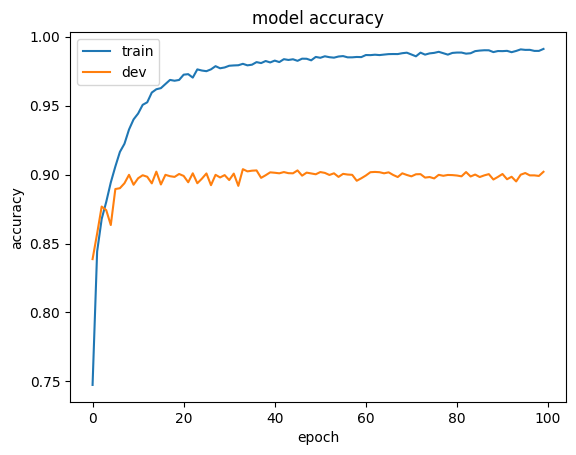

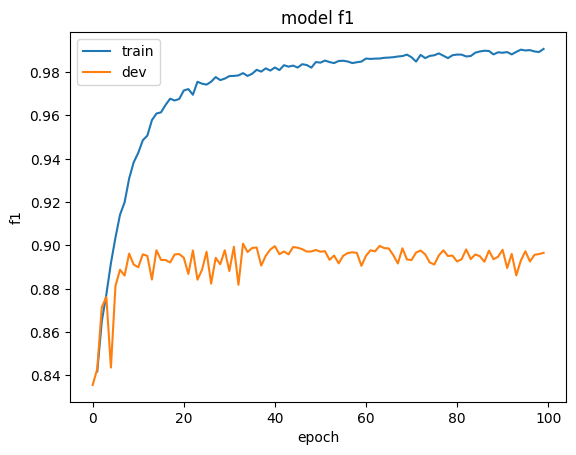

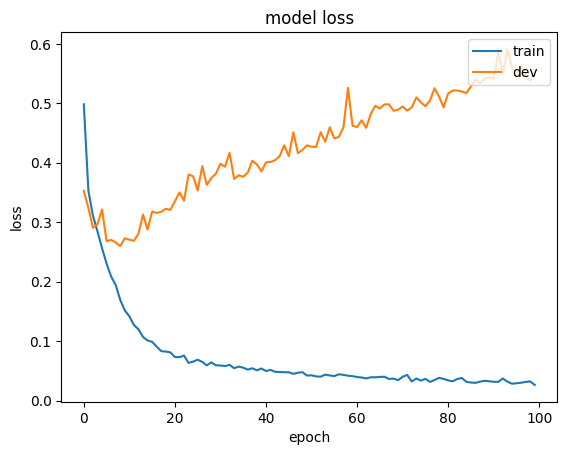

In [ ]:
training_history(history2)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def predict_data(data):
    T = model.predict(data)
    # T2 = np.zeros_like(T)
    # for i in range(T.shape[0]):
    #   T2[i] = T[i]/np.max(T[i])
    C = np.ones((T.shape[1],)) / 2
    T = (C<=T)
    return T*1


print(f'Dev accuracy: {accuracy_score(y_dev, predict_data(X_dev))*100:.2f}%')
print(f'Dev micro-f1: {f1_score(y_dev, predict_data(X_dev), average="micro")*100:.2f}%')
print(f'Test accuracy: {accuracy_score(y_test, predict_data(X_test))*100:.2f}%')
print(f'Test micro-f1: {f1_score(y_test, predict_data(X_test), average="micro")*100:.2f}%')

313/313 [==============================] - 4s 12ms/step
Dev accuracy: 90.20%
313/313 [==============================] - 4s 11ms/step
Dev micro-f1: 90.20%
313/313 [==============================] - 4s 12ms/step
Test accuracy: 90.58%
313/313 [==============================] - 4s 12ms/step
Test micro-f1: 90.58%


### **Tune the simple CNN (1st Implemention) (Keras-Tuner)**

In [27]:
#!pip install keras-tuner
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input, Embedding, concatenate
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from sklearn.model_selection import train_test_split



def build_model(hp):
    FILTERS = hp.Int('filters', min_value=64, max_value=128, step=32)
    DENSE = hp.Int('dense_units', min_value=64, max_value=512, step=64)
    DROP_RATE = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    
    inputs = Input(shape=(1,), dtype=tf.string)
    x = vectorizer(inputs)
    
    # Embeddings
    embeddings = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM,
                           weights=[embedding_matrix],
                           input_length=MAX_SEQUENCE_LENGTH,
                           trainable=False)(x)
    
    # Dropout over Embeddings
    dropped_embeddings = Dropout(rate=DROP_RATE)(embeddings)
    
    # Multi-filter CNNs
    pooled_convs = []
    conv_layers = []
    filter_sizes = [2, 3, 4]

    for n_gram in filter_sizes:
        for i in range(3):
            # n-gram convolutions with padding
            convs = Conv1D(
                filters=FILTERS, kernel_size=n_gram,
                strides=1, padding="same", activation='relu',
                name='{}.{}-gram_Convolutions'.format(n_gram, i))(dropped_embeddings)
            conv_layers.append(convs) # store the convolution layers
    
        if len(conv_layers) > 1:
            concatenated_conv = concatenate(conv_layers) # concatenate all the layers
        else:
            concatenated_conv = conv_layers[0]
            
        # Max-Pooling over time 
        pooled_convs.append(
            GlobalMaxPooling1D(name='{}-gram_MaxPool'.format(n_gram))(concatenated_conv) # Max pool each stack of Conv layers
        )

    # Concatenation of filters from all window sizes
    concat = concatenate(pooled_convs)
    concat = Dropout(rate=DROP_RATE)(concat)
    outputs = Dense(1, activation='sigmoid')(concat)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(),
                  metrics=[precision, recall, f1, accuracy])
    
    return model

tuner = RandomSearch(
    build_model,
    objective='accuracy',
    max_trials=29, 
    executions_per_trial=1,
    directory='tuning_directory',
    project_name='cnn_tuning'
)

tuner.search_space_summary()

tuner.search(np.array(X_train), y_train,
             epochs=30,
             validation_data=(np.array(X_dev), y_dev),
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=5)])

best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(best_hyperparameters)

print("Summary of the Best Model:")
print(best_model.summary())

Trial 7 Complete [00h 11m 58s]
accuracy: 0.9318333268165588

Best accuracy So Far: 0.9781333208084106
Total elapsed time: 00h 58m 59s

Search: Running Trial #8

Value             |Best Value So Far |Hyperparameter
96                |96                |filters
448               |192               |dense_units
0.3               |0.2               |dropout_rate

Epoch 1/30
938/938 [==============================] - 37s 38ms/step - loss: 0.4992 - precision: 0.7495 - recall: 0.7710 - f1: 0.7470 - accuracy: 0.7509 - val_loss: 0.3533 - val_precision: 0.8262 - val_recall: 0.8679 - val_f1: 0.8424 - val_accuracy: 0.8442
Epoch 2/30
938/938 [==============================] - 36s 38ms/step - loss: 0.3556 - precision: 0.8404 - recall: 0.8576 - f1: 0.8430 - accuracy: 0.8459 - val_loss: 0.3194 - val_precision: 0.8787 - val_recall: 0.8358 - val_f1: 0.8526 - val_accuracy: 0.8608
Epoch 3/30
938/938 [==============================] - 36s 38ms/step - loss: 0.3173 - precision: 0.8626 - recall: 0.8710 - f1: 

KeyboardInterrupt: 

* Evaluate the best model from the tuner

In [28]:
from sklearn.metrics import accuracy_score, f1_score

best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(best_hyperparameters)

print("Summary of the Best Model:")
print(best_model.summary())

def predict_data(data):
    T = best_model.predict(data)
    # T2 = np.zeros_like(T)
    # for i in range(T.shape[0]):
    #   T2[i] = T[i]/np.max(T[i])
    C = np.ones((T.shape[1],)) / 2
    T = (C<=T)
    return T*1


print(f'Dev accuracy: {accuracy_score(y_dev, predict_data(X_dev))*100:.2f}%')
print(f'Dev micro-f1: {f1_score(y_dev, predict_data(X_dev), average="micro")*100:.2f}%')
print(f'Test accuracy: {accuracy_score(y_test, predict_data(X_test))*100:.2f}%')
print(f'Test micro-f1: {f1_score(y_test, predict_data(X_test), average="micro")*100:.2f}%')

Best Hyperparameters:
Summary of the Best Model:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 text_vectorization (TextVector  (None, 266)         0           ['input_1[0][0]']                
 ization)                                                                                         
                                                                                                  
 embedding (Embedding)          (None, 266, 300)     30000000    ['text_vectorization[9][0]']     
                                                                                                  
 dropout (Dropout)              (None, 266, 3

# Results
* We will calculate precision, recall, F1, PR-auc scores first for each class and then macro average.

313/313 [==============================] - 145s 462ms/step


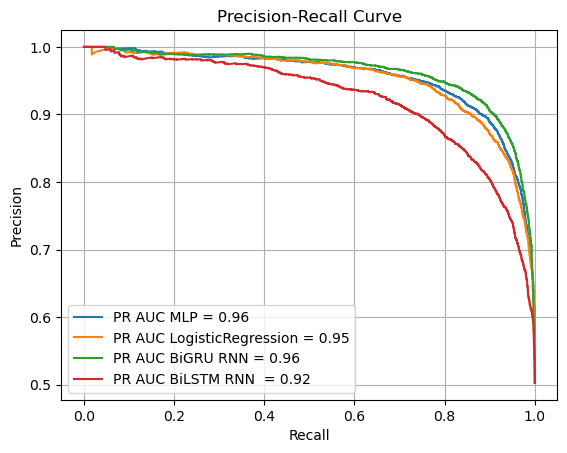

In [ ]:
# Calculate model predictions (Multi Layer Perceptron Baseline-2)
y_pred = mlp.predict(X_test_svd)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Compute PR AUC
pr_auc = auc(recall, precision)

# Plot the PR curve for our model
plt.figure()
plt.plot(recall, precision, label='PR AUC MLP = %0.2f' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')


# Predict probabilities (Logistic Regression Baseline-1)
probs = clf.predict_proba(X_test_svd)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Calculate area under the curve (AUC) for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve for baseline model
plt.plot(recall, precision, label=f'PR AUC LogisticRegression = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)



# Predict probabilities of X_test using BiDirectional GRU + deep Self attention
y_pred = biGRU_deep_selfatt.predict(np.array(X_test))
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Compute PR AUC
pr_auc = auc(recall, precision)

# Plot the PR curve for our model
plt.plot(recall, precision, label='PR AUC BiGRU RNN = %0.2f' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')



# Predict probabilities of X_test using BiDirectional LSTM + linear Self attention
y_pred = stacked_bilstm_selfattn.predict(np.array(X_test))
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Compute PR AUC
pr_auc = auc(recall, precision)

# Plot the PR curve for our model
plt.plot(recall, precision, label='PR AUC BiLSTM RNN  = %0.2f' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')




## Sum up Classification Reports + AUC Scores

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, auc, precision_recall_curve, roc_auc_score

# Calculate predictions for clf
train_preds_clf = clf.predict_proba(X_train_svd)
train_preds_bin_clf = clf.predict(X_train_svd)

dev_preds_clf = clf.predict_proba(X_dev_svd)
dev_preds_bin_clf = clf.predict(X_dev_svd)

test_preds_clf = clf.predict_proba(X_test_svd)
test_preds_bin_clf = clf.predict(X_test_svd)




# Calculate predictions for BiGRU with deep self attention 
# predict train data
train_preds_biGRU = biGRU_deep_selfatt.predict(np.array(X_train))
train_preds_bin_biGRU = np.array([[1] if pred >= 0.5 else [0] for pred in train_preds_biGRU])

# predict dev data
dev_preds_biGRU = biGRU_deep_selfatt.predict(np.array(X_dev))
dev_preds_bin_biGRU = np.array([[1] if pred >= 0.5 else [0] for pred in dev_preds_biGRU])

# predict test data
test_preds_biGRU = biGRU_deep_selfatt.predict(np.array(X_test))
test_preds_bin_biGRU = np.array([[1] if pred >= 0.5 else [0] for pred in test_preds_biGRU])



# Calculate predictions for BiLSTM with linear self attention 
# predict train data
train_preds_biLSTM = stacked_bilstm_selfattn.predict(np.array(X_train))
train_preds_bin_biLSTM = np.array([[1] if pred >= 0.5 else [0] for pred in train_preds_biLSTM])

# predict dev data
dev_preds_biLSTM = stacked_bilstm_selfattn.predict(np.array(X_dev))
dev_preds_bin_biLSTM = np.array([[1] if pred >= 0.5 else [0] for pred in dev_preds_biLSTM])

# predict test data
test_preds_biLSTM = stacked_bilstm_selfattn.predict(np.array(X_test))
test_preds_bin_biLSTM = np.array([[1] if pred >= 0.5 else [0] for pred in test_preds_biLSTM])



313/313 [==============================] - 525s 2s/step


In [ ]:
# Calculate predictions for MLP
# predict train data
train_preds_mlp = mlp.predict(X_train_svd)
train_preds_bin_mlp = np.array([[1] if pred >= 0.5 else [0] for pred in train_preds_mlp])

# predict dev data
dev_preds_mlp = mlp.predict(X_dev_svd)
dev_preds_bin_mlp = np.array([[1] if pred >= 0.5 else [0] for pred in dev_preds_mlp])

# predict test data
test_preds_mlp = mlp.predict(X_test_svd)
test_preds_bin_mlp = np.array([[1] if pred >= 0.5 else [0] for pred in test_preds_mlp])


313/313 [==============================] - 1s 2ms/step


In [ ]:
from operator import pos
from sklearn.metrics import precision_recall_curve, average_precision_score

# Define a function to calculate metrics for each class including PR-AUC for MLP
def calculate_class_metrics_model(y_true, y_pred, y_probs):
    report = classification_report(y_true, y_pred, output_dict=True)
    # For class 1
    class_0_metrics = report['0']
    # For class 2
    class_1_metrics = report['1']

    # Calculate PR-AUC for each class
    precision, recall, _ = precision_recall_curve(y_true, y_probs, pos_label=1)
    pr_auc_class_1 = auc(recall, precision)

    # Its binary problem so 1-probability is the probability for class 0
    y_probs = 1-y_probs
    precision, recall, _ = precision_recall_curve(y_true, y_probs, pos_label=0)
    pr_auc_class_0 = auc(recall, precision)

    return class_0_metrics, class_1_metrics, pr_auc_class_0, pr_auc_class_1

# Define a function to calculate metrics for each class including PR-AUC for Logistic
def calculate_class_metrics_clf(y_true, y_pred, y_probs):
    report = classification_report(y_true, y_pred, output_dict=True)
    class_0_metrics = report['0']
    class_1_metrics = report['1']

    # Calculate PR-AUC for each class
    precision, recall, _ = precision_recall_curve(y_true, y_probs[:, 1],pos_label=1)
    pr_auc_class_1 = auc(recall, precision)

    precision, recall, _ = precision_recall_curve(y_true, y_probs[:, 0],pos_label=0)
    pr_auc_class_0 = auc(recall, precision)

    return class_0_metrics, class_1_metrics, pr_auc_class_0, pr_auc_class_1



# Calculate class metrics for clf
class_0_metrics_train_clf, class_1_metrics_train_clf, pr_auc_0_train_clf, pr_auc_1_train_clf = calculate_class_metrics_clf(y_train, train_preds_bin_clf, train_preds_clf)
class_0_metrics_dev_clf, class_1_metrics_dev_clf, pr_auc_0_dev_clf, pr_auc_1_dev_clf = calculate_class_metrics_clf(y_dev, dev_preds_bin_clf, dev_preds_clf)
class_0_metrics_test_clf, class_1_metrics_test_clf, pr_auc_0_test_clf, pr_auc_1_test_clf = calculate_class_metrics_clf(y_test, test_preds_bin_clf, test_preds_clf)

# Calculate class metrics for MLP
class_0_metrics_train_mlp, class_1_metrics_train_mlp, pr_auc_0_train_mlp, pr_auc_1_train_mlp = calculate_class_metrics_model(y_train, train_preds_bin_mlp, train_preds_mlp)
class_0_metrics_dev_mlp, class_1_metrics_dev_mlp, pr_auc_0_dev_mlp, pr_auc_1_dev_mlp = calculate_class_metrics_model(y_dev, dev_preds_bin_mlp, dev_preds_mlp)
class_0_metrics_test_mlp, class_1_metrics_test_mlp, pr_auc_0_test_mlp, pr_auc_1_test_mlp = calculate_class_metrics_model(y_test, test_preds_bin_mlp,test_preds_mlp)

# Calculate class metrics for BiLSTM
class_0_metrics_train_biLSTM, class_1_metrics_train_biLSTM, pr_auc_0_train_biLSTM, pr_auc_1_train_biLSTM = calculate_class_metrics_model(y_train, train_preds_bin_biLSTM, train_preds_biLSTM)
class_0_metrics_dev_biLSTM, class_1_metrics_dev_biLSTM, pr_auc_0_dev_biLSTM, pr_auc_1_dev_biLSTM = calculate_class_metrics_model(y_dev, dev_preds_bin_biLSTM, dev_preds_biLSTM)
class_0_metrics_test_biLSTM, class_1_metrics_test_biLSTM, pr_auc_0_test_biLSTM, pr_auc_1_test_biLSTM = calculate_class_metrics_model(y_test, test_preds_bin_biLSTM,test_preds_biLSTM)


# Calculate class metrics for BiGRU
class_0_metrics_train_biGRU, class_1_metrics_train_biGRU, pr_auc_0_train_biGRU, pr_auc_1_train_biGRU = calculate_class_metrics_model(y_train, train_preds_bin_biGRU, train_preds_biGRU)
class_0_metrics_dev_biGRU, class_1_metrics_dev_biGRU, pr_auc_0_dev_biGRU, pr_auc_1_dev_biGRU = calculate_class_metrics_model(y_dev, dev_preds_bin_biGRU, dev_preds_biGRU)
class_0_metrics_test_biGRU, class_1_metrics_test_biGRU, pr_auc_0_test_biGRU, pr_auc_1_test_biGRU = calculate_class_metrics_model(y_test, test_preds_bin_biGRU,test_preds_biGRU)


# Create separate DataFrames for training, development, and test results for each class
train_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'MLP', 'biLSTM','biGRU'],
    'Class 0 Precision': [class_0_metrics_train_clf['precision'], class_0_metrics_train_mlp['precision'],class_0_metrics_train_biLSTM['precision'],class_0_metrics_train_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_train_clf['precision'], class_1_metrics_train_mlp['precision'],class_1_metrics_train_biLSTM['precision'],class_1_metrics_train_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_train_clf['recall'], class_0_metrics_train_mlp['recall'],class_0_metrics_train_biLSTM['recall'],class_0_metrics_train_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_train_clf['recall'], class_1_metrics_train_mlp['recall'],class_1_metrics_train_biLSTM['recall'],class_1_metrics_train_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_train_clf['f1-score'], class_0_metrics_train_mlp['f1-score'],class_0_metrics_train_biLSTM['f1-score'],class_0_metrics_train_biGRU['f1-score']],
    'Class 1 F1-score': [class_1_metrics_train_clf['f1-score'], class_1_metrics_train_mlp['f1-score'],class_1_metrics_train_biLSTM['f1-score'],class_1_metrics_train_biGRU['f1-score']],
    'PR AUC Class 0': [pr_auc_0_train_clf, pr_auc_0_train_mlp,pr_auc_0_train_biLSTM,pr_auc_0_train_biGRU],
    'PR AUC Class 1': [pr_auc_1_train_clf, pr_auc_1_train_mlp,pr_auc_1_train_biLSTM,pr_auc_1_train_biGRU]
})

dev_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'MLP', 'biLSTM', 'biGRU'],
    'Class 0 Precision': [class_0_metrics_dev_clf['precision'], class_0_metrics_dev_mlp['precision'],class_0_metrics_dev_biLSTM['precision'],class_0_metrics_dev_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_dev_clf['precision'], class_1_metrics_dev_mlp['precision'],class_1_metrics_dev_biLSTM['precision'],class_1_metrics_dev_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_dev_clf['recall'], class_0_metrics_dev_mlp['recall'],class_0_metrics_dev_biLSTM['recall'],class_0_metrics_dev_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_dev_clf['recall'], class_1_metrics_dev_mlp['recall'],class_1_metrics_dev_biLSTM['recall'],class_1_metrics_dev_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_dev_clf['f1-score'], class_0_metrics_dev_mlp['f1-score'],class_0_metrics_dev_biLSTM['f1-score'],class_0_metrics_dev_biGRU['f1-score']],
    'Class 1 F1-score': [class_1_metrics_dev_clf['f1-score'], class_1_metrics_dev_mlp['f1-score'],class_1_metrics_dev_biLSTM['f1-score'],class_1_metrics_dev_biGRU['f1-score']],
    'PR AUC Class 0': [pr_auc_0_dev_clf, pr_auc_0_dev_mlp,pr_auc_0_dev_biLSTM,pr_auc_0_dev_biGRU],
    'PR AUC Class 1': [pr_auc_1_dev_clf, pr_auc_1_dev_mlp,pr_auc_1_dev_biLSTM,pr_auc_1_dev_biGRU]
})

test_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'MLP', 'biLSTM', 'biGRU'],
    'Class 0 Precision': [class_0_metrics_test_clf['precision'], class_0_metrics_test_mlp['precision'], class_0_metrics_test_biLSTM['precision'],class_0_metrics_test_biGRU['precision']],
    'Class 1 Precision': [class_1_metrics_test_clf['precision'], class_1_metrics_test_mlp['precision'],class_1_metrics_test_biLSTM['precision'],class_1_metrics_test_biGRU['precision']],
    'Class 0 Recall': [class_0_metrics_test_clf['recall'], class_0_metrics_test_mlp['recall'],class_0_metrics_test_biLSTM['recall'],class_1_metrics_test_biGRU['recall']],
    'Class 1 Recall': [class_1_metrics_test_clf['recall'], class_1_metrics_test_mlp['recall'],class_1_metrics_test_biLSTM['recall'],class_1_metrics_test_biGRU['recall']],
    'Class 0 F1-score': [class_0_metrics_test_clf['f1-score'], class_0_metrics_test_mlp['f1-score'],class_0_metrics_test_biLSTM['f1-score'],class_1_metrics_test_biLSTM['f1-score']],
    'Class 1 F1-score': [class_1_metrics_test_clf['f1-score'], class_1_metrics_test_mlp['f1-score'],class_1_metrics_test_biLSTM['f1-score'],class_1_metrics_test_biLSTM['f1-score']],
    'PR AUC Class 0': [pr_auc_0_test_clf, pr_auc_0_test_mlp,pr_auc_0_test_biLSTM,pr_auc_0_test_biLSTM],
    'PR AUC Class 1': [pr_auc_1_test_clf, pr_auc_1_test_mlp,pr_auc_1_test_biLSTM,pr_auc_0_test_biLSTM]
})

from tabulate import tabulate

# Print training class metrics
print("Training Class Metrics:")
print(tabulate(train_class_metrics_df, headers='keys', tablefmt='psql'))

# Print development class metrics
print("\nDevelopment Class Metrics:")
print(tabulate(dev_class_metrics_df, headers='keys', tablefmt='psql'))

# Print test class metrics
print("\nTest Class Metrics:")
print(tabulate(test_class_metrics_df, headers='keys', tablefmt='psql'))


Training Class Metrics:
+----+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+------------------+------------------+
|    | Classifier   |   Class 0 Precision |   Class 1 Precision |   Class 0 Recall |   Class 1 Recall |   Class 0 F1-score |   Class 1 F1-score |   PR AUC Class 0 |   PR AUC Class 1 |
|----+--------------+---------------------+---------------------+------------------+------------------+--------------------+--------------------+------------------+------------------|
|  0 | LR           |            0.900292 |            0.88501  |         0.882702 |         0.902293 |           0.89141  |           0.893568 |         0.960301 |         0.958453 |
|  1 | MLP          |            0.927662 |            0.95137  |         0.952654 |         0.925753 |           0.939992 |           0.938387 |         0.985251 |         0.985183 |
|  2 | biLSTM       |            0.854084 |            0

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, auc
import pandas as pd

def calculate_metrics(y_true, y_pred, y_probs):
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    precision_auc, recall_auc, _ = precision_recall_curve(y_true, y_probs)
    pr_auc = auc(recall_auc, precision_auc)
    return precision, recall, f1, pr_auc

# Calculate class metrics for clf
precision_train_clf, recall_train_clf, f1_train_clf, pr_auc_train_clf = calculate_metrics(y_train, train_preds_bin_clf, train_preds_clf[:,1])
precision_dev_clf, recall_dev_clf, f1_dev_clf, pr_auc_dev_clf = calculate_metrics(y_dev, dev_preds_bin_clf, dev_preds_clf[:,1])
precision_test_clf, recall_test_clf, f1_test_clf, pr_auc_test_clf = calculate_metrics(y_test, test_preds_bin_clf, test_preds_clf[:,1])

# Calculate class metrics for model
precision_train_mlp, recall_train_mlp, f1_train_mlp, pr_auc_train_mlp = calculate_metrics(y_train, train_preds_bin_mlp, train_preds_mlp)
precision_dev_mlp, recall_dev_mlp, f1_dev_mlp, pr_auc_dev_mlp = calculate_metrics(y_dev, dev_preds_bin_mlp, dev_preds_mlp)
precision_test_mlp, recall_test_mlp, f1_test_mlp, pr_auc_test_mlp = calculate_metrics(y_test, test_preds_bin_mlp,test_preds_mlp)

# Calculate class metrics for biLSTM
precision_train_biLSTM, recall_train_biLSTM, f1_train_biLSTM, pr_auc_train_biLSTM = calculate_metrics(y_train, train_preds_bin_biLSTM, train_preds_biLSTM)
precision_dev_biLSTM, recall_dev_biLSTM, f1_dev_biLSTM, pr_auc_dev_biLSTM = calculate_metrics(y_dev, dev_preds_bin_biLSTM, dev_preds_biLSTM)
precision_test_biLSTM, recall_test_biLSTM, f1_test_biLSTM, pr_auc_test_biLSTM = calculate_metrics(y_test, test_preds_bin_biLSTM,test_preds_biLSTM)


# Calculate class metrics for biGRU
precision_train_biGRU, recall_train_biGRU, f1_train_biGRU, pr_auc_train_biGRU = calculate_metrics(y_train, train_preds_bin_biGRU, train_preds_biGRU)
precision_dev_biGRU, recall_dev_biGRU, f1_dev_biGRU, pr_auc_dev_biGRU = calculate_metrics(y_dev, dev_preds_bin_biGRU, dev_preds_biGRU)
precision_test_biGRU, recall_test_biGRU, f1_test_biGRU, pr_auc_test_biGRU = calculate_metrics(y_test, test_preds_bin_biGRU,test_preds_biGRU)




# Create separate DataFrames for training, development, and test results for each class
train_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'MLP', 'biLSTM', 'biGRU'],
    'Precision': [precision_train_clf, precision_train_mlp,precision_train_biLSTM,precision_train_biGRU],
    'Recall': [recall_train_clf, recall_train_mlp,recall_train_biLSTM,recall_train_biGRU],
    'F1': [f1_train_clf, f1_train_mlp,f1_train_biLSTM,f1_train_biGRU],
    'PR AUC': [pr_auc_train_clf, pr_auc_train_mlp,pr_auc_train_biLSTM,pr_auc_train_biGRU]
})

dev_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'MLP', 'biLSTM', 'biGRU'],
    'Precision': [precision_train_clf, precision_dev_mlp, precision_dev_biLSTM,precision_dev_biGRU],
    'Recall': [recall_dev_clf, recall_dev_mlp,recall_dev_biLSTM,recall_dev_biGRU],
    'F1': [f1_dev_clf, f1_dev_mlp,f1_dev_biLSTM,f1_dev_biGRU],
    'PR AUC': [pr_auc_dev_clf, pr_auc_dev_mlp,pr_auc_dev_biLSTM,pr_auc_dev_biGRU]
})

test_class_metrics_df = pd.DataFrame({
    'Classifier': ['LR', 'MLP', 'biLSTM', 'biGRU'],
    'Precision': [precision_test_clf, precision_test_mlp,precision_test_biLSTM,precision_test_biGRU],
    'Recall': [recall_test_clf, recall_test_mlp,recall_test_biLSTM,recall_test_biGRU],
    'F1': [f1_test_clf, f1_test_mlp,f1_test_biLSTM,f1_test_biGRU],
    'PR AUC': [pr_auc_test_clf, pr_auc_test_mlp,pr_auc_test_biLSTM,pr_auc_test_biGRU]
})

from tabulate import tabulate

# Print training class metrics
print("Training Class Metrics:")
print(tabulate(train_class_metrics_df, headers='keys', tablefmt='psql'))

# Print development class metrics
print("\nDevelopment Class Metrics:")
print(tabulate(dev_class_metrics_df, headers='keys', tablefmt='psql'))

# Print test class metrics
print("\nTest Class Metrics:")
print(tabulate(test_class_metrics_df, headers='keys', tablefmt='psql'))


Training Class Metrics:
+----+--------------+-------------+----------+----------+----------+
|    | Classifier   |   Precision |   Recall |       F1 |   PR AUC |
|----+--------------+-------------+----------+----------+----------|
|  0 | LR           |    0.892651 | 0.892497 | 0.892489 | 0.958453 |
|  1 | MLP          |    0.939516 | 0.939204 | 0.939189 | 0.985183 |
|  2 | biLSTM       |    0.856212 | 0.856201 | 0.856199 | 0.930473 |
|  3 | biGRU        |    0.962918 | 0.962899 | 0.9629   | 0.993177 |
+----+--------------+-------------+----------+----------+----------+

Development Class Metrics:
+----+--------------+-------------+----------+----------+----------+
|    | Classifier   |   Precision |   Recall |       F1 |   PR AUC |
|----+--------------+-------------+----------+----------+----------|
|  0 | LR           |    0.892651 | 0.885274 | 0.885278 | 0.953649 |
|  1 | MLP          |    0.888608 | 0.888236 | 0.888177 | 0.958003 |
|  2 | biLSTM       |    0.84834  | 0.848312 | 0.84